In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/marketing_campaign_features.csv")

In [2]:
print(df.shape)
df

(2236, 34)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Response,Edad,Gasto_Total,Compras_Totales,Campañas_Aceptadas,Dependientes,Antiguedad_Cliente,Segmento_Valor
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,1,57,1617,22,0,0,663,Alto
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,60,27,4,0,2,113,Bajo
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,49,776,20,0,0,312,Medio
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,30,53,6,0,1,139,Bajo
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,33,422,14,0,1,161,Medio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,0,47,1341,16,0,1,381,Alto
2232,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,0,0,68,444,15,1,3,19,Medio
2233,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,0,0,33,1241,18,1,0,155,Alto
2234,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,0,58,843,21,0,1,156,Alto


In [3]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

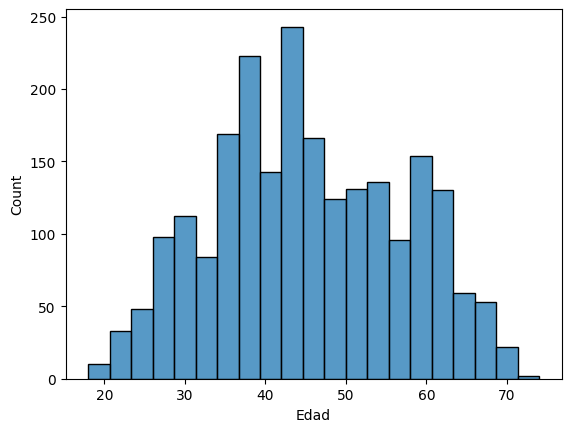

In [4]:
sns.histplot(data=df, x="Edad")
plt.show()

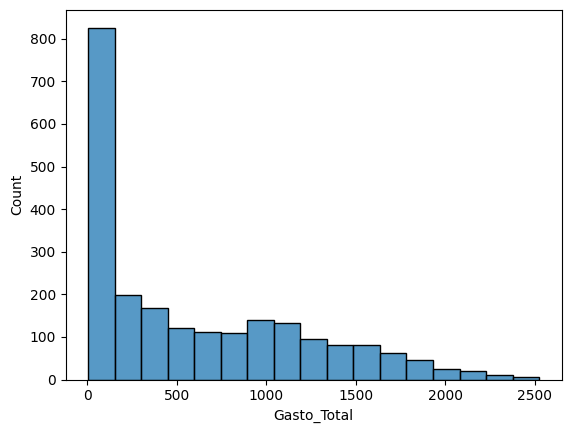

In [5]:
sns.histplot(data=df, x="Gasto_Total")
plt.show()

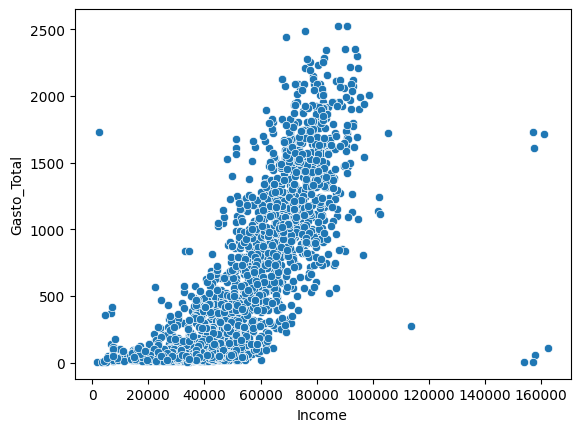

In [6]:
sns.scatterplot(data=df, x="Income", y="Gasto_Total")
plt.show()

In [7]:
df["Gasto_Total"].quantile([0.33, 0.66])

0.33    110.65
0.66    813.20
Name: Gasto_Total, dtype: float64

In [8]:
df["Segmento_Valor"].value_counts()

Segmento_Valor
Alto     760
Bajo     738
Medio    738
Name: count, dtype: int64

In [9]:
pd.crosstab(df["Segmento_Valor"], df["Response"])

Response,0,1
Segmento_Valor,,
Alto,573,187
Bajo,682,56
Medio,647,91


In [10]:
pd.crosstab(df["Segmento_Valor"], df["Response"], normalize="index")

Response,0,1
Segmento_Valor,,
Alto,0.753947,0.246053
Bajo,0.924119,0.075881
Medio,0.876694,0.123306


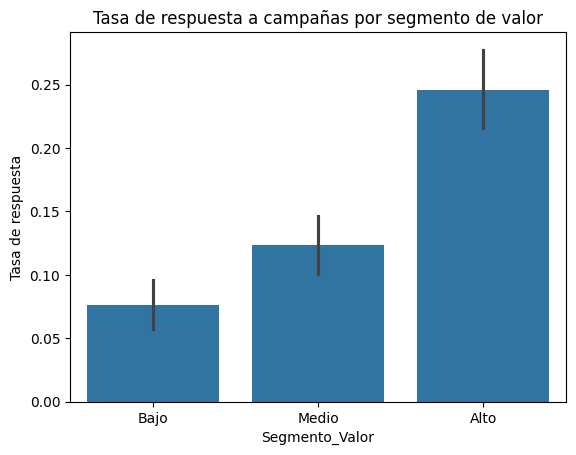

In [11]:
sns.barplot(data=df, x="Segmento_Valor", y="Response", order=["Bajo", "Medio", "Alto"])
plt.title("Tasa de respuesta a campañas por segmento de valor")
plt.ylabel("Tasa de respuesta")
plt.show()

In [12]:
alto_no_responde = df[(df["Segmento_Valor"] == "Alto") & (df["Response"] == 0)]
alto_no_responde.shape

(573, 34)

In [13]:
alto_si_responde = df[(df["Segmento_Valor"] == "Alto") & (df["Response"] == 1)]
alto_si_responde.shape

(187, 34)

In [14]:
print("Alto valor, NO responde - Recency promedio:", alto_no_responde["Recency"].mean())
print("Alto valor, SÍ responde - Recency promedio:", alto_si_responde["Recency"].mean())

Alto valor, NO responde - Recency promedio: 53.53752181500872
Alto valor, SÍ responde - Recency promedio: 40.032085561497325


In [15]:
print("Alto valor, NO responde - Campañas aceptadas promedio:", alto_no_responde["Campañas_Aceptadas"].mean())
print("Alto valor, SÍ responde - Campañas aceptadas promedio:", alto_si_responde["Campañas_Aceptadas"].mean())

Alto valor, NO responde - Campañas aceptadas promedio: 0.39092495636998253
Alto valor, SÍ responde - Campañas aceptadas promedio: 1.3796791443850267


In [16]:
medio_no_responde = df[(df["Segmento_Valor"] == "Medio") & (df["Response"] == 0)]
medio_no_responde.shape

(647, 34)

In [17]:
medio_si_responde = df[(df["Segmento_Valor"] == "Medio") & (df["Response"] == 1)]
medio_si_responde.shape

(91, 34)

In [18]:
print("Medio valor, NO responde - Recency promedio:", medio_no_responde["Recency"].mean())
print("Medio valor, SÍ responde - Recency promedio:", medio_si_responde["Recency"].mean())

Medio valor, NO responde - Recency promedio: 50.82534775888717
Medio valor, SÍ responde - Recency promedio: 31.307692307692307


In [19]:
print("Medio valor, NO responde - Campañas aceptadas promedio:", medio_no_responde["Campañas_Aceptadas"].mean())
print("Medio valor, SÍ responde - Campañas aceptadas promedio:", medio_si_responde["Campañas_Aceptadas"].mean())

Medio valor, NO responde - Campañas aceptadas promedio: 0.1143740340030912
Medio valor, SÍ responde - Campañas aceptadas promedio: 0.5384615384615384


In [20]:
bajo_no_responde = df[(df["Segmento_Valor"] == "Bajo") & (df["Response"] == 0)]
bajo_no_responde.shape

(682, 34)

In [21]:
bajo_si_responde = df[(df["Segmento_Valor"] == "Bajo") & (df["Response"] == 1)]
bajo_si_responde.shape

(56, 34)

In [22]:
print("Bajo valor, NO responde - Recency promedio:", bajo_no_responde["Recency"].mean())
print("Bajo valor, SÍ responde - Recency promedio:", bajo_si_responde["Recency"].mean())

Bajo valor, NO responde - Recency promedio: 50.5058651026393
Bajo valor, SÍ responde - Recency promedio: 26.482142857142858


In [23]:
print("Bajo valor, NO responde - Campañas aceptadas promedio:", bajo_no_responde["Campañas_Aceptadas"].mean())
print("Bajo valor, SÍ responde - Campañas aceptadas promedio:", bajo_si_responde["Campañas_Aceptadas"].mean())

Bajo valor, NO responde - Campañas aceptadas promedio: 0.05571847507331378
Bajo valor, SÍ responde - Campañas aceptadas promedio: 0.4107142857142857


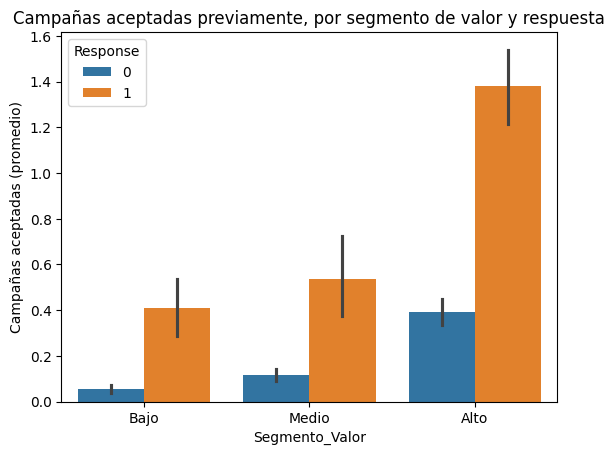

In [24]:
sns.barplot(data=df, x="Segmento_Valor", y="Campañas_Aceptadas", hue="Response", order=["Bajo", "Medio", "Alto"])
plt.title("Campañas aceptadas previamente, por segmento de valor y respuesta")
plt.ylabel("Campañas aceptadas (promedio)")
plt.show()

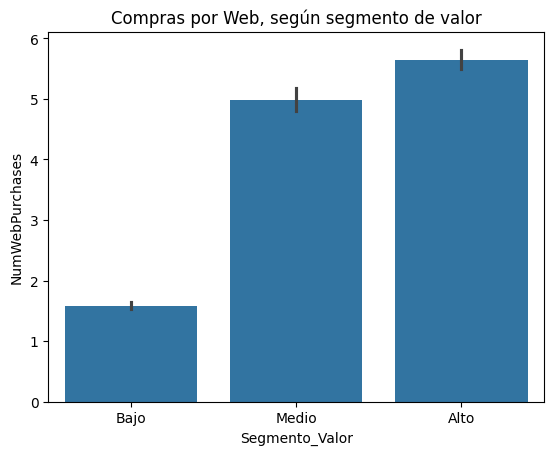

In [25]:
sns.barplot(data=df, x="Segmento_Valor", y="NumWebPurchases", order=["Bajo", "Medio", "Alto"])
plt.title("Compras por Web, según segmento de valor")
plt.show()

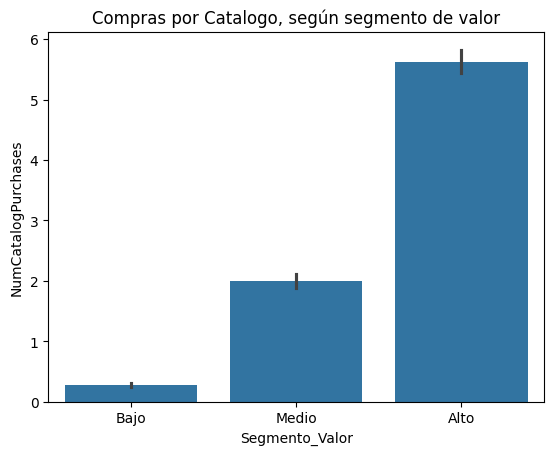

In [26]:
sns.barplot(data=df, x="Segmento_Valor", y="NumCatalogPurchases", order=["Bajo", "Medio", "Alto"])
plt.title("Compras por Catalogo, según segmento de valor")
plt.show()

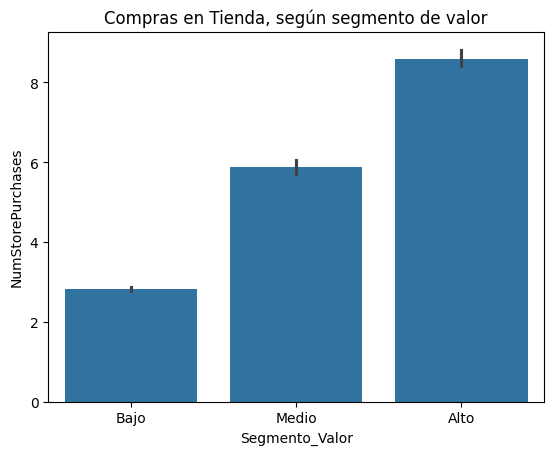

In [27]:
sns.barplot(data=df, x="Segmento_Valor", y="NumStorePurchases", order=["Bajo", "Medio", "Alto"])
plt.title("Compras en Tienda, según segmento de valor")
plt.show()

## Análisis — Insights y Recomendaciones

**Segmentación de clientes por valor:**
Se dividió a los clientes en 3 segmentos (Bajo, Medio, Alto) según su gasto total 
en los últimos 2 años, usando percentiles (33% y 66%) para un reparto equilibrado 
(~738 clientes por segmento).

**Hallazgo 1 — Valor del cliente y respuesta a campañas están relacionados:**
Los clientes de Alto valor responden a campañas 3.2 veces más que los de Bajo valor 
(24.6% vs 7.6%).

**Hallazgo 2 — El historial de campañas es el predictor más fuerte de respuesta:**
Dentro de cada segmento de valor, los clientes que ya habían aceptado campañas 
anteriores tienen entre 3.5x y 7.3x más probabilidad de responder a la campaña 
actual, comparado con quienes no tenían historial de aceptación. Este patrón es 
más consistente que la recencia de compra (Recency).

**Hallazgo 3 — El canal de Catálogo diferencia fuertemente a los clientes de alto valor:**
Los clientes de Alto valor compran ~19 veces más por catálogo que los de Bajo valor, 
una diferencia mucho más marcada que en Web o Tienda física.

**Recomendaciones de negocio:**
1. Priorizar el presupuesto de marketing en clientes con historial de respuesta 
   previa ("repeat responders"), independientemente de su segmento de valor.
2. Para clientes de Alto valor sin historial de respuesta, considerar estrategias 
   de reactivación específicas antes de incluirlos en campañas masivas.
3. Evaluar el canal de catálogo como vía prioritaria de comunicación con clientes 
   de alto valor.